In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X = df.drop(columns = 'species')
Y = df['species']

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [5]:
X_scaled = sc.fit_transform(X)

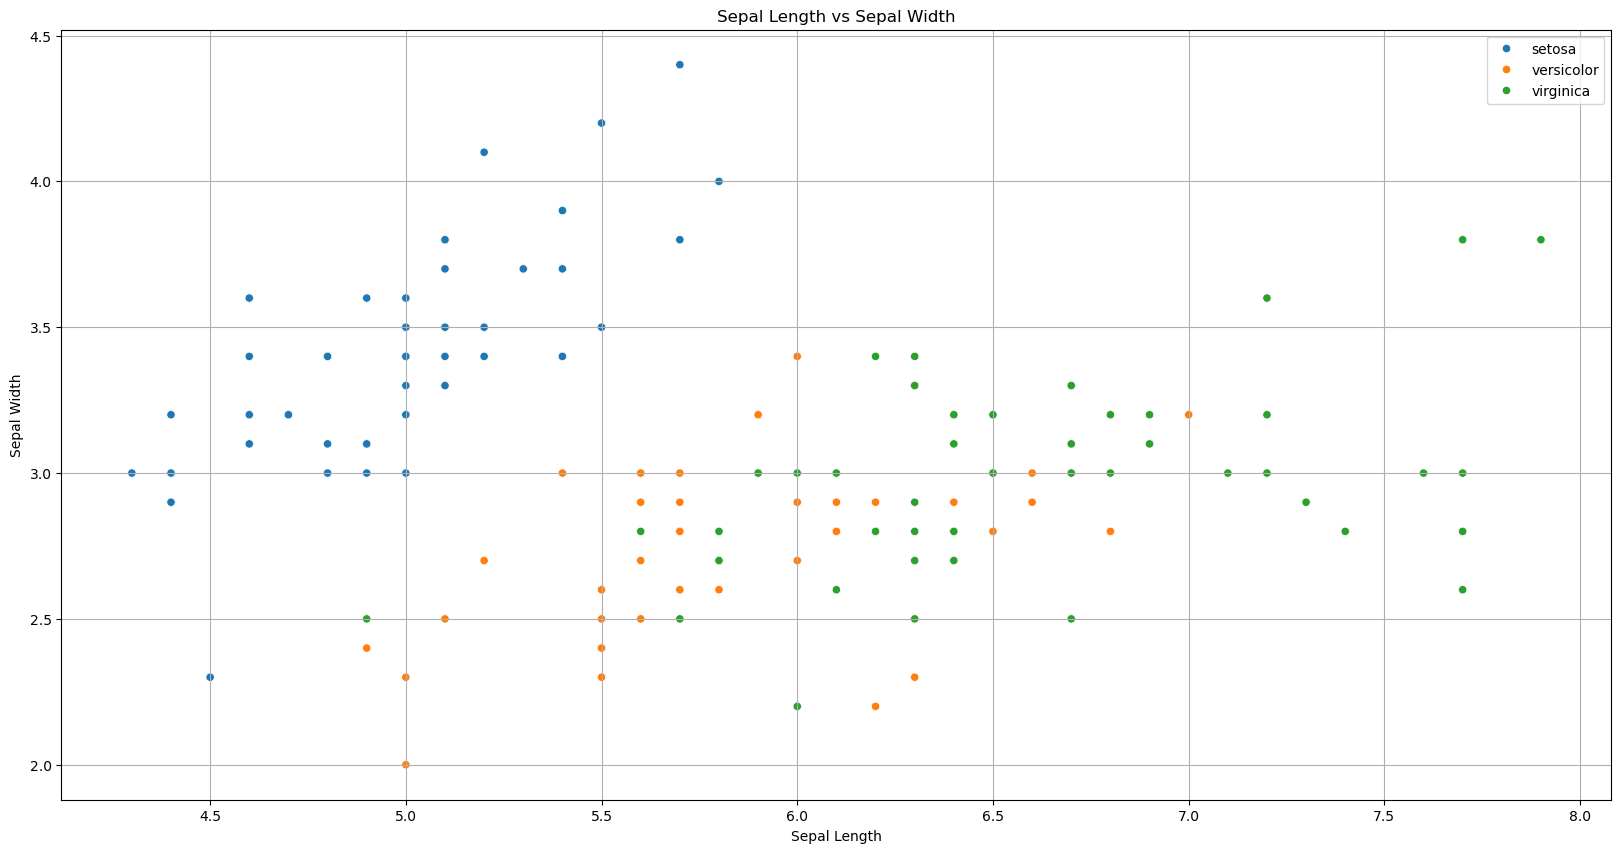

In [6]:
plt.figure(figsize = (20,10))
sns.scatterplot(data = df,x = 'sepal_length',y = 'sepal_width',hue = df['species'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Sepal Length vs Sepal Width')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
from sklearn.cluster import KMeans

In [8]:
kmeans = KMeans(n_clusters = 3,random_state = 42)
df['cluster'] = kmeans.fit_predict(X_scaled)
centroids_scaled = kmeans.cluster_centers_
centroids_original = sc.inverse_transform(centroids_scaled)

In [9]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,2
2,4.7,3.2,1.3,0.2,setosa,2
3,4.6,3.1,1.5,0.2,setosa,2
4,5.0,3.6,1.4,0.2,setosa,1


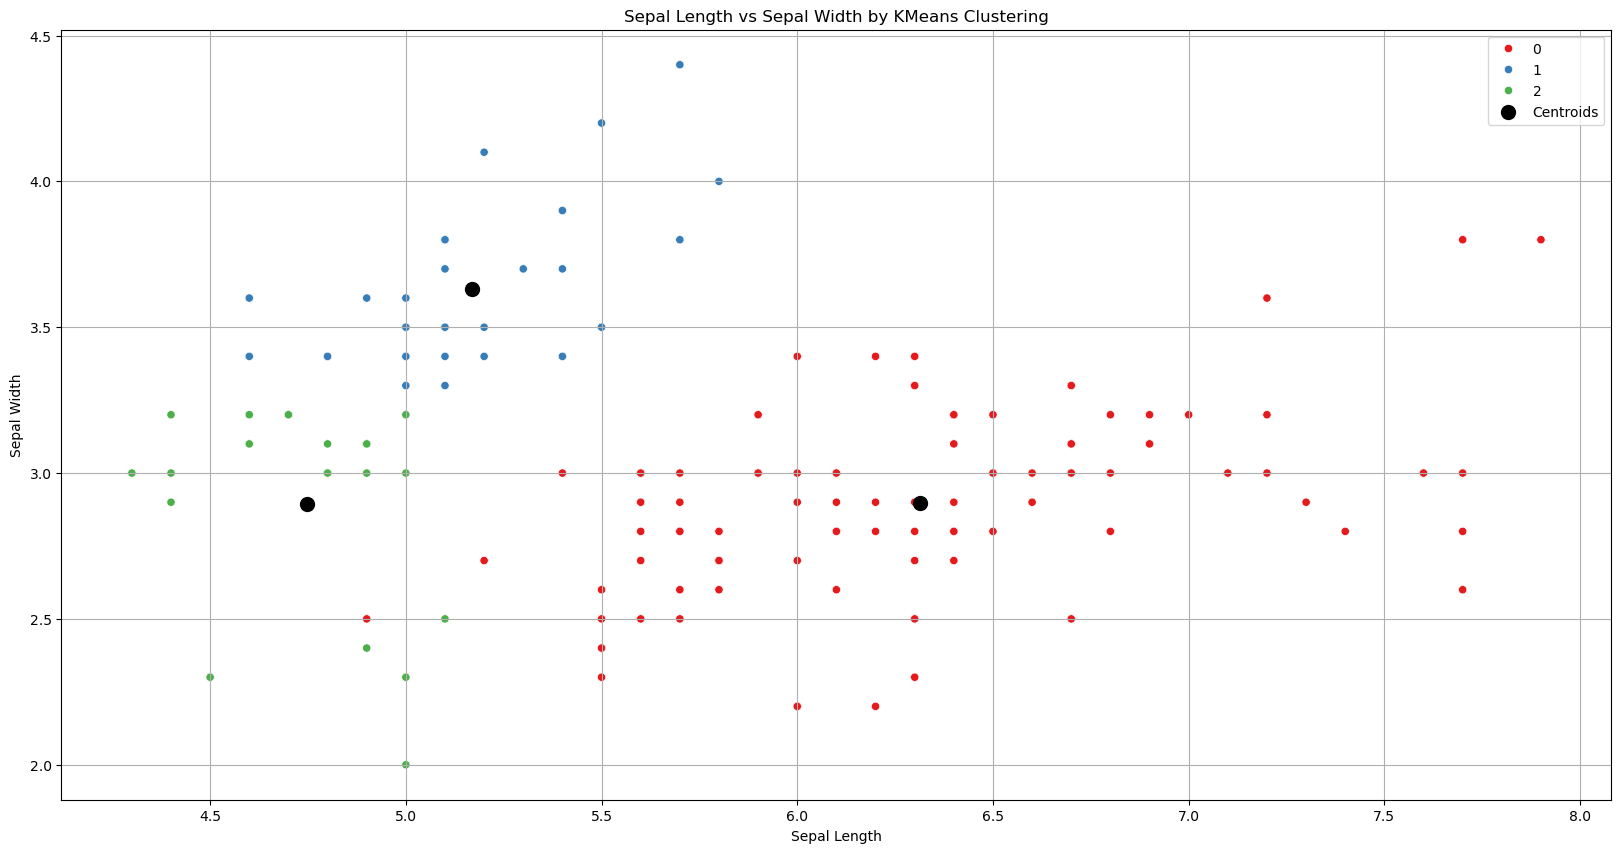

In [10]:
plt.figure(figsize = (20,10))
sns.scatterplot(data = df,x = 'sepal_length',y = 'sepal_width',hue = df['cluster'],palette = 'Set1')
plt.scatter(centroids_original[:,0],centroids_original[:,1],s = 100,c = 'black',marker = 'o',label = 'Centroids')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Sepal Length vs Sepal Width by KMeans Clustering')
plt.grid(True)
plt.legend()
plt.show()

In [11]:
inertias = []
k_range = range(1,11)
for i in k_range:
    kmeans = KMeans(n_clusters = i,random_state = 42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

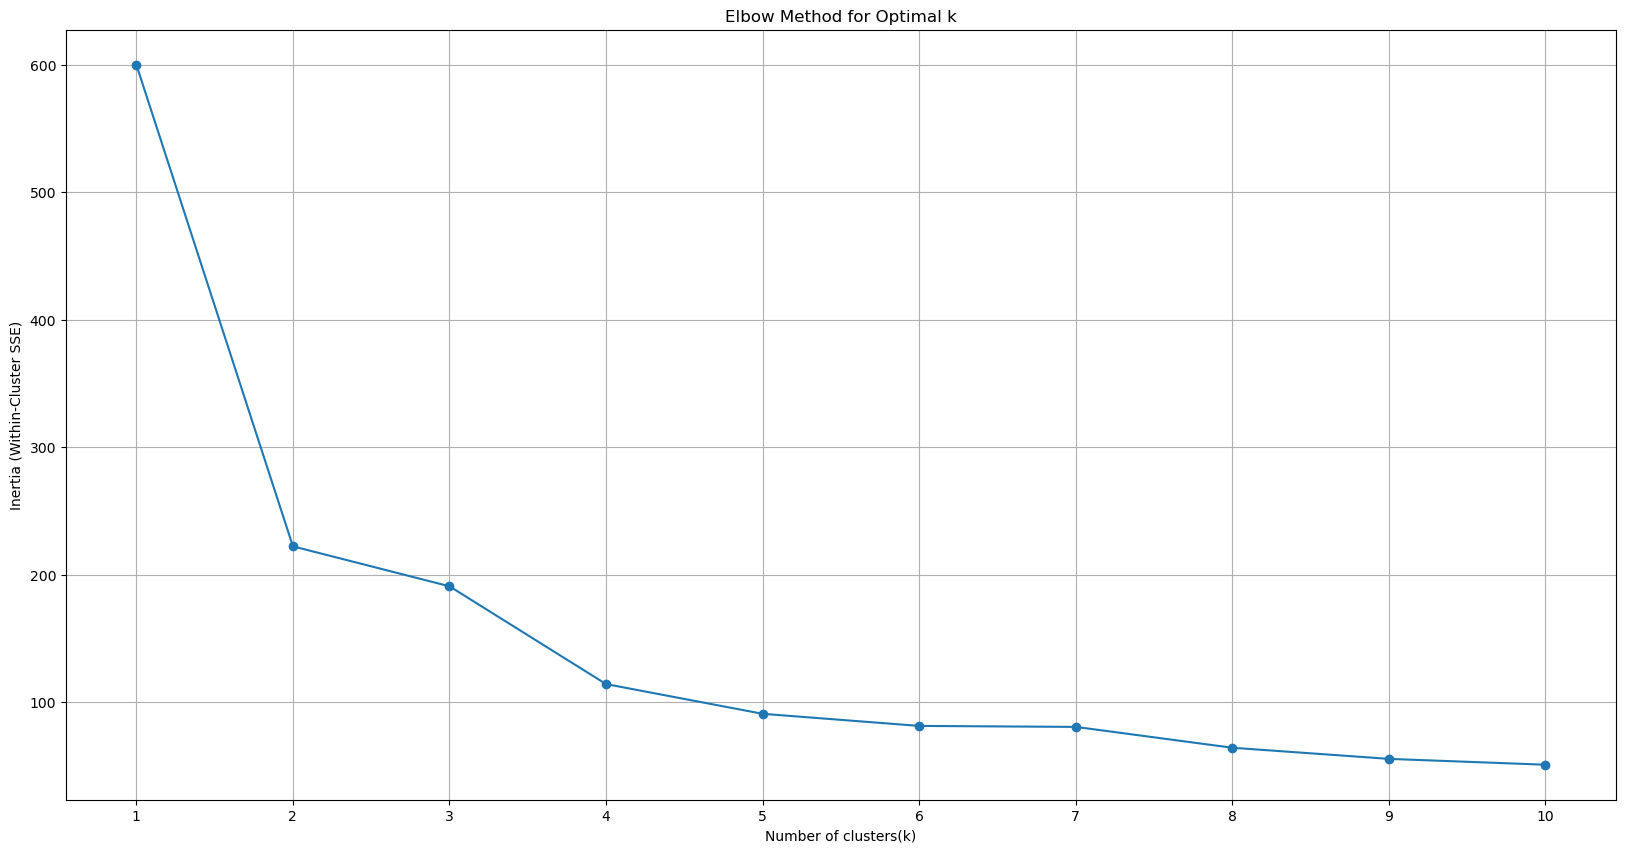

In [12]:
plt.figure(figsize = (20,10))
plt.plot(k_range,inertias,marker = 'o')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.xticks(k_range)
plt.show()